# **1. Importing Necessary Libraries**

In [1]:
# Data Analysis
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import random
import warnings
plt.style.use('ggplot')
from huggingface_hub import hf_hub_download
import zipfile

# Ignore warnings
warnings.filterwarnings('ignore')

In [15]:
# Download the zip file
zip_path = hf_hub_download(
    repo_id="seyeddd/Solar-PV-Clean-Hotspot-Images",
    filename="clean_vs_single_hotspot.zip",       # The file in "Files and versions"
    repo_type="dataset"
)

clean_vs_single_hotspot.zip:   0%|          | 0.00/1.08G [00:00<?, ?B/s]

In [16]:
# Extract to a local folder
extract_dir = "/content/dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Check folder structure
os.listdir(extract_dir)

['Dataset']

# **2. Define Directories**

In [17]:
# Directories
base_dir = "/content/dataset/Dataset"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
valid_dir = os.path.join(base_dir, "valid")

In [18]:
# Reproducability
random.seed(42)
np.random.seed(42)

# **3. Data Analysis**

## **3.1 Image Count Analysis**

In [19]:
# Count images in each category
data_counts = {}
for split in ['train', 'test', 'valid']:
  split_dir = os.path.join(base_dir, split)
  data_counts[split] = {}

  for category in ['single_hotspot', 'clean']:
    category_dir = os.path.join(split_dir, category)
    if os.path.exists(category_dir):
      num_images = len(os.listdir(category_dir))
      data_counts[split][category] = num_images
      print(f"{split} / {category}: {num_images} images")
    else:
      data_counts[split][category] = 0

train / single_hotspot: 1749 images
train / clean: 1078 images
test / single_hotspot: 400 images
test / clean: 300 images
valid / single_hotspot: 400 images
valid / clean: 300 images


## **3.2 Class Distribution Analysis**

In [20]:
def view_class_distribution(data_counts):
  """
  Displays class distributions (Hotspot/clean) for a folder.

  Args:
        data_counts: The counts for the respective folder.
  """

  plt.pie(data_counts, labels=['Single Hotspot', 'Clean'], autopct='%1.1f%%',
          colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0.05, 0))
  plt.title(f'Class Distribution (n = {sum(data_counts)})')
  plt.show()

In [21]:
# Get each counts for each folder
train_counts = [data_counts['train']['single_hotspot'], data_counts['train']['clean']]
test_counts = [data_counts['test']['single_hotspot'], data_counts['test']['clean']]
val_counts = [data_counts['valid']['single_hotspot'], data_counts['valid']['clean']]

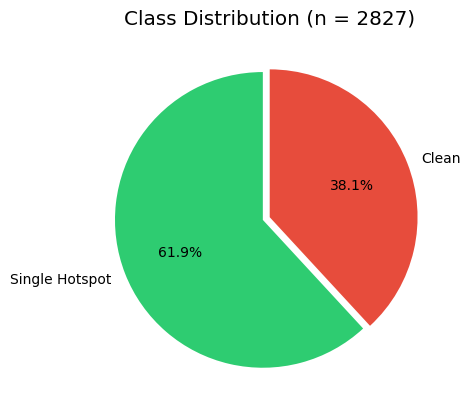

In [22]:
# Train class distribution
view_class_distribution(train_counts)

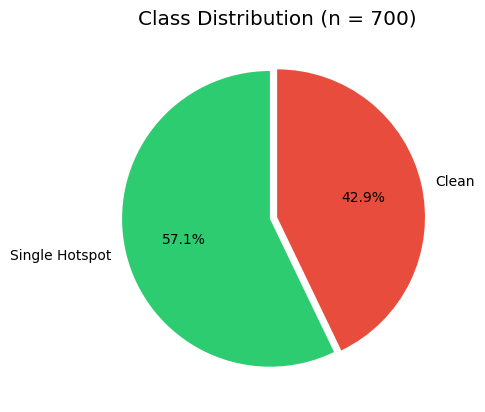

In [23]:
# Test class distribution
view_class_distribution(test_counts)

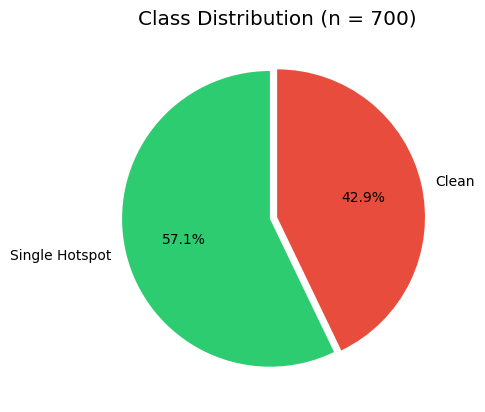

In [24]:
# Valid class distribution
view_class_distribution(val_counts)

## **3.3 Ratio Analysis**

In [25]:
# Compute class imbalance ratio in the training set
ratio = data_counts['train']['single_hotspot'] / data_counts['train']['clean']
print(f"Class Imbalance Ratio: {ratio:.3f}")

Class Imbalance Ratio: 1.622


## **3.4 Duplicate Image Analysis**

## **3.5 Sample Images Analysis**

In [26]:
# List to store all samples
samples = []

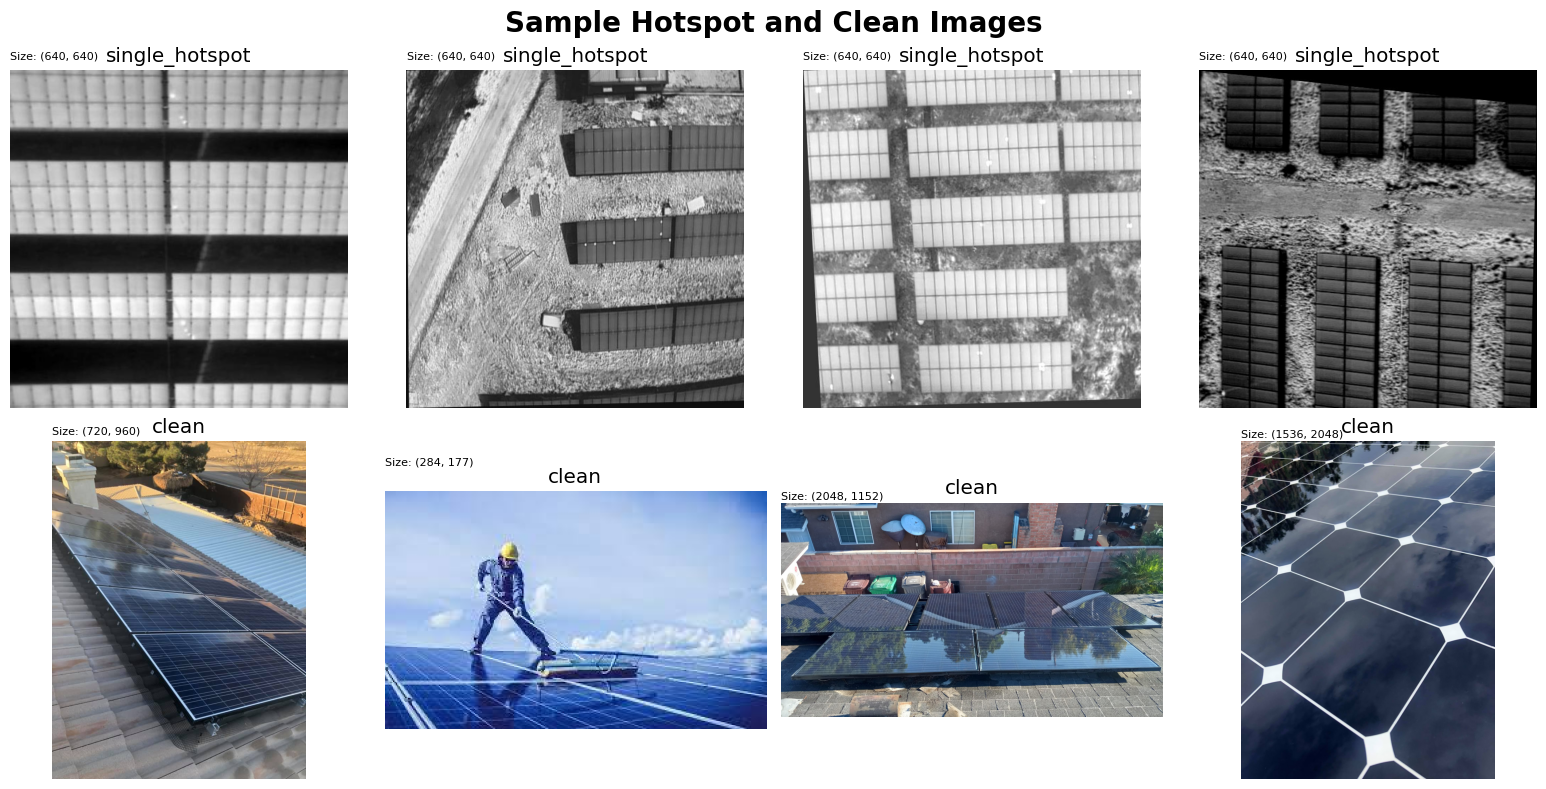

In [27]:
# Prepare plotting for both labels
fig, axes = plt.subplots(2,4, figsize=(16,8))

for label in ['single_hotspot', 'clean']:
  label_path = os.path.join(train_dir, label)
  img_files = [f for f in os.listdir(label_path) if f.endswith(('.jpeg', '.jpg', '.png'))]

  # Random 4 samples (filenames) for the current label
  selected_filenames = random.sample(img_files, 4)

  for img_file_name in selected_filenames:
    img_path = os.path.join(label_path, img_file_name)
    img = Image.open(img_path)
    samples.append((img, label))

# Display samples
for i, tup in enumerate(samples):
  row = i // 4
  col = i % 4

  axes[row, col].imshow(tup[0], cmap='gray')
  axes[row, col].set_title(tup[1])
  axes[row, col].axis('off')

  axes[row, col].text(0, -20, f'Size: {tup[0].size}', fontsize=8)

plt.suptitle('Sample Hotspot and Clean Images', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

## **3.6 Dimension Analysis**

In [28]:
# Prepare a dimensions array to store all dimensions
dimensions = []

# Append first 50 image dimensions per category
for category in ['single_hotspot', 'clean']:
  category_dir = os.path.join(train_dir, category)
  image_files = [f for f in os.listdir(category_dir) if f.endswith(('.jpeg', '.jpg', '.png'))]

  # First 50 images
  for img_file in image_files[:50]:
    path = os.path.join(category_dir, img_file)
    img = Image.open(path)
    dimensions.append(img.size)

In [29]:
# Convert to a NumPy array
dimensions = np.array(dimensions)

In [30]:
# Get widths and heights
widths = dimensions[:, 0]
heights = dimensions[:, 1]

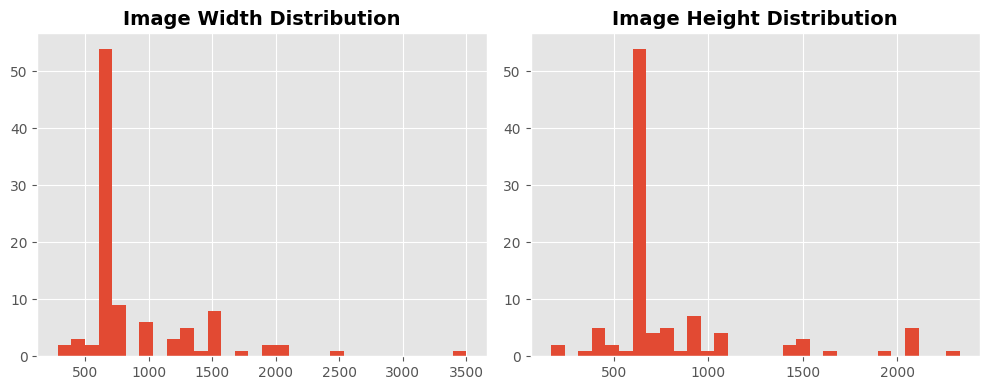

In [31]:
# Plot the distributions
plt.figure(figsize=(10, 4))

# Width
plt.subplot(1,2,1)
plt.hist(widths, bins=30)
plt.title('Image Width Distribution', fontweight='bold', fontsize=14)

plt.subplot(1,2,2)
plt.hist(heights, bins=30)
plt.title('Image Height Distribution', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## **3.7 Pixel Intensity Analysis**

In [32]:
def plot_pixel_intensity(label):
  """
  Plots pixel intensity distribution for a given label.

  Args:
    label: The class label being analysed.
  """

  sample_img_dir = os.path.join(train_dir, label)
  sample_img_name = os.listdir(sample_img_dir)[0]
  img = cv2.imread(os.path.join(sample_img_dir, sample_img_name), cv2.IMREAD_GRAYSCALE)

  # Prepare for plotting
  plt.hist(img.ravel(), bins=256)
  plt.title(f"Pixel Intensity Distribution ({label})", fontweight='bold', fontsize=16)
  plt.xlabel('Pixel Value')
  plt.ylabel('Frequency')
  plt.show()

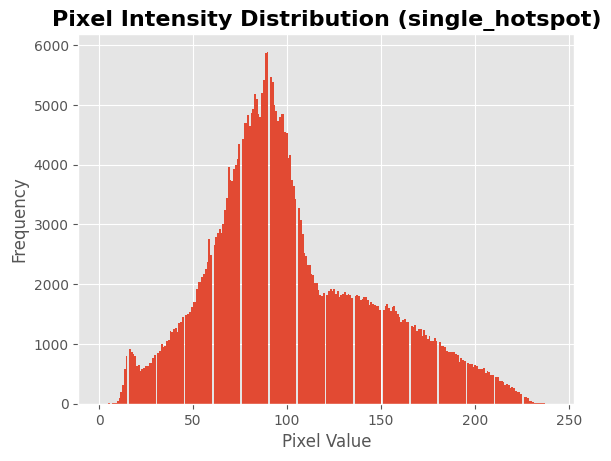

In [33]:
# Distribution for single hotspot
plot_pixel_intensity('single_hotspot')

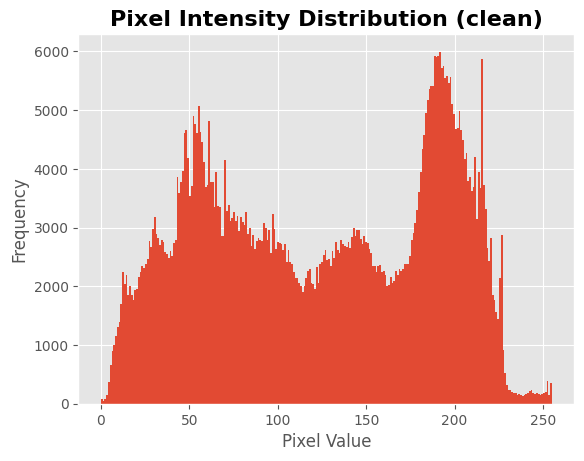

In [34]:
# Distribution for clean
plot_pixel_intensity('clean')

In [35]:
def plot_pixel_kde(folder, class_name, sample_size=20):
  """
  Plots kernel density estimation for pixel intensities in a folder.

  Args:
    folder: The folder being used.
    class_name: Which class name to plot the pixel kde.
    sample_size: The number of images to sample.
  """

  # Get all image files
  img_files = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
  img_files = random.sample(img_files, min(sample_size, len(img_files)))

  # Get all pixel values
  pixel_values = []
  for f in img_files:
    img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
    pixel_values.extend(img.ravel())  # Flatten all pixels

  # Prepare kernel density plot
  sns.kdeplot(pixel_values, fill=True, bw_adjust=0.5)
  plt.title(f"KDE of Pixel Intensities ({class_name})", fontsize=14, fontweight='bold')
  plt.xlabel("Pixel Value")
  plt.ylabel("Density")
  plt.show()

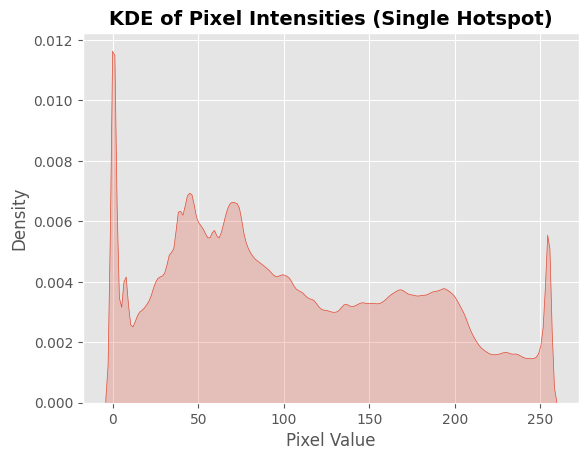

In [36]:
# Get pixel KDE for single hotspot
plot_pixel_kde(os.path.join(train_dir, 'single_hotspot'), 'Single Hotspot')

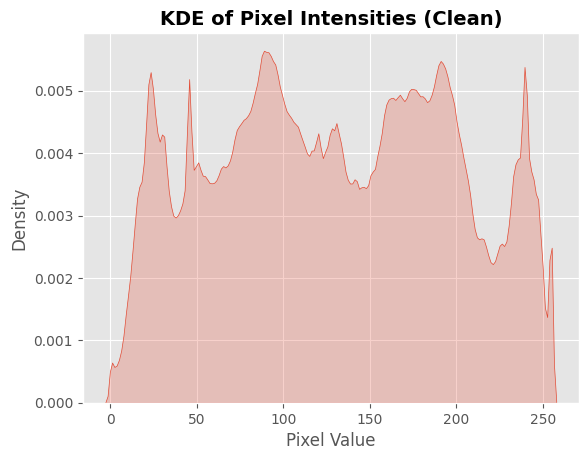

In [37]:
# Get pixel KDE for clean
plot_pixel_kde(os.path.join(train_dir, 'clean'), 'Clean')

In [38]:
# Define list to store all features (Containing mean pixel, max pixel and the respective class)
features = []

# Loop through each category
for category in ['single_hotspot', 'clean']:
    folder = os.path.join(train_dir, category)
    files = random.sample(os.listdir(folder), 50)  # sample 50 images
    for f in files:
        img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
        features.append({
            'MeanPixel': np.mean(img),
            'MaxPixel': np.max(img),
            'Class': category
        })

In [39]:
# Convert to a pandas dataframe
feat_df = pd.DataFrame(features)

In [40]:
def jointplot(label, color, title):
  """
  Plots jointplot for a given label for max pixel against mean pixel

  Args:
    label: Which class level for the jointplot to be shown.
    color:  The color of the density plot.
    title: The title of the respective plot.
  """

  sns.jointplot(
      data=feat_df[feat_df['Class']==label],
      x='MeanPixel', y='MaxPixel',
      kind='kde',
      fill=True, cmap=color
  )
  plt.suptitle(f"Pixel Value Density: {title}", fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.show()

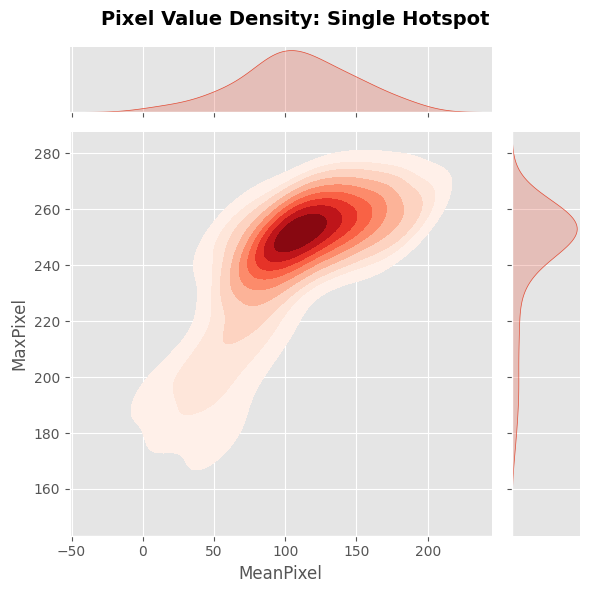

In [41]:
# Jointplot for single hotspot
jointplot('single_hotspot', 'Reds', 'Single Hotspot')

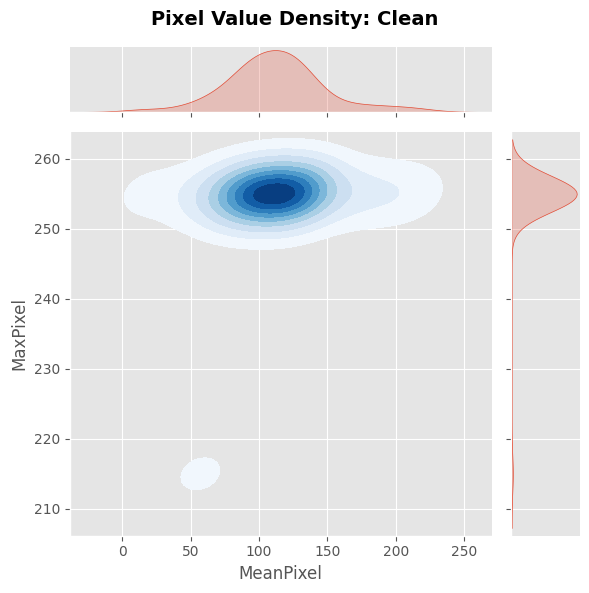

In [42]:
# Jointplot for clean
jointplot('clean', 'Blues', 'Clean')